Classes:
  0: Early Blight
  1: Late Blight
  2: Healthy

Number of classes: 3

Dataset sizes:
Training:   1506
Validation: 323
Test:       323

Image shape: (96, 96, 3)

Training class distribution:
  Early Blight: 700
  Late Blight: 700
  Healthy: 106

Class weights:
  Early Blight: 0.717
  Late Blight: 0.717
  Healthy: 4.736


Model: "PotatoDiseaseMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ potato_leaf_image (InputLayer)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease_prediction (Dense)      │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20


c:\Users\HP\Downloads\Plant Dieases Classification Model\.myvenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7683 - loss: 0.6083
Epoch 1: val_accuracy improved from None to 0.82663, saving model to ../ml/potato_mobilenet.keras

Epoch 1: finished saving model to ../ml/potato_mobilenet.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 361ms/step - accuracy: 0.7683 - loss: 0.6083 - val_accuracy: 0.8266 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 2/20
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9069 - loss: 0.2246
Epoch 2: val_accuracy improved from 0.82663 to 0.89164, saving model to ../ml/potato_mobilenet.keras

Epoch 2: finished saving model to ../ml/potato_mobilenet.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step - accuracy: 0.9064 - loss: 0.2248 - val_accuracy: 0.8916 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 3/20
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9222 - loss: 0.1697
Epoch 3: val_accuracy improved from 0.89164 to 0.93808, saving model to ../ml/potato_mobilenet.keras

Epoch 3: finished saving model to ../ml/

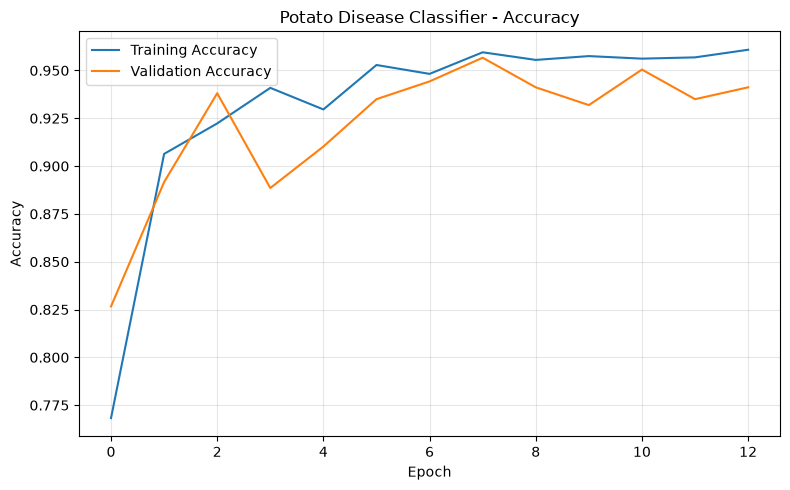

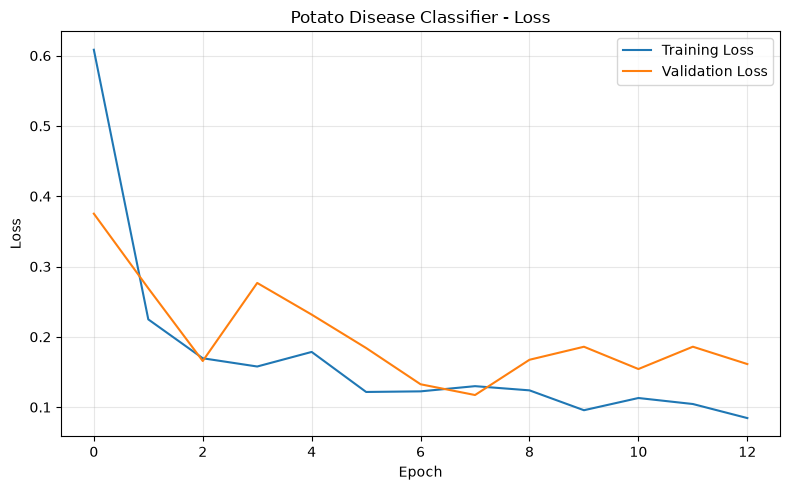

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9474 - loss: 0.1361

TEST ACCURACY: 0.9474
TEST LOSS: 0.1361
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 392ms/step

Classification Report:

              precision    recall  f1-score   support

Early Blight       0.99      0.99      0.99       150
 Late Blight       0.99      0.90      0.94       150
     Healthy       0.62      1.00      0.77        23

    accuracy                           0.95       323
   macro avg       0.87      0.96      0.90       323
weighted avg       0.96      0.95      0.95       323


Confusion Matrix:
[[148   2   0]
 [  1 135  14]
 [  0   0  23]]


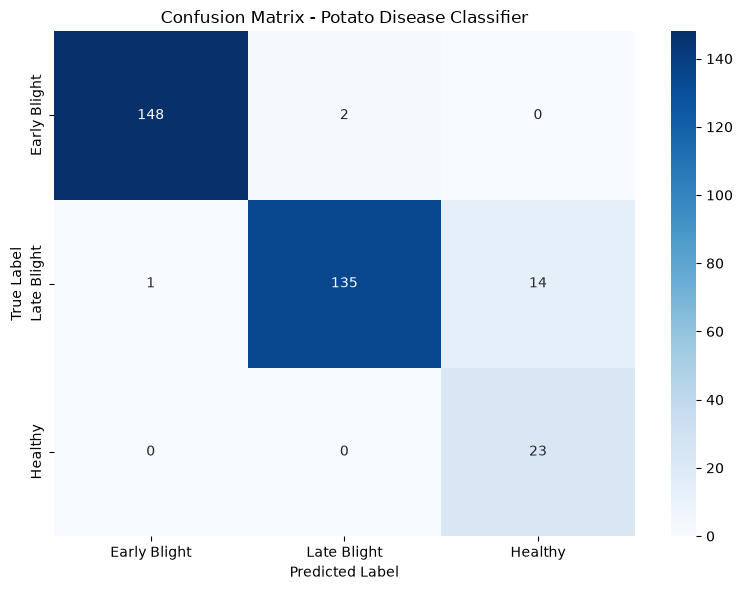

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

with open('../data/processed/potato_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train = splits['X_train']
y_train = splits['y_train']

X_val = splits['X_val']
y_val = splits['y_val']

X_test = splits['X_test']
y_test = splits['y_test']

CLASSES = splits['classes']
CLASS_DISPLAY = splits['class_display']

NUM_CLASSES = len(CLASSES)

print("Classes:")
for i, class_name in enumerate(CLASSES):
    print(f"  {i}: {CLASS_DISPLAY[class_name]}")

print(f"\nNumber of classes: {NUM_CLASSES}")

print("\nDataset sizes:")
print(f"Training:   {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test:       {len(X_test)}")


# ============================================================
# 2. CHECK IMAGE SHAPE
# ============================================================

print(f"\nImage shape: {X_train.shape[1:]}")


# ============================================================
# 3. CLASS DISTRIBUTION
# ============================================================

print("\nTraining class distribution:")

for class_id, class_name in enumerate(CLASSES):
    count = np.sum(y_train == class_id)
    print(f"  {CLASS_DISPLAY[class_name]}: {count}")


# ============================================================
# 4. CALCULATE CLASS WEIGHTS
# ============================================================

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("\nClass weights:")

for class_id, weight in class_weights.items():
    print(
        f"  {CLASS_DISPLAY[CLASSES[class_id]]}: "
        f"{weight:.3f}"
    )


# ============================================================
# 5. CREATE TF.DATA DATASET
# ============================================================

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(X_train),
    reshuffle_each_iteration=True
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)


# Validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)


# Test dataset
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)


# ============================================================
# 6. DATA AUGMENTATION
# ============================================================
# Augmentation is applied ONLY during training.
# Validation and test images remain unchanged.

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        mode='horizontal'
    ),

    layers.RandomRotation(
        factor=0.07
    ),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomBrightness(
        factor=0.15
    )
], name="data_augmentation")


# ============================================================
# 7. BUILD MOBILENETV2
# ============================================================

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained MobileNetV2
base_model.trainable = False


# ============================================================
# 8. BUILD COMPLETE MODEL
# ============================================================

inputs = layers.Input(
    shape=(96, 96, 3),
    name="potato_leaf_image"
)

# Training augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = preprocess_input(x)

# Feature extraction
x = base_model(
    x,
    training=False
)

# Convert feature maps into one feature vector
x = layers.GlobalAveragePooling2D()(x)

# Classification head
x = layers.Dropout(0.3)(x)

x = layers.Dense(
    128,
    activation='relu'
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    name="disease_prediction"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="PotatoDiseaseMobileNetV2"
)


# ============================================================
# 9. COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)


# ============================================================
# 10. MODEL SUMMARY
# ============================================================

model.summary()


# ============================================================
# 11. TRAIN MODEL
# ============================================================

EPOCHS = 20

history = model.fit(
    train_dataset,

    epochs=EPOCHS,

    validation_data=val_dataset,

    class_weight=class_weights,

    callbacks=[
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        ),

        ModelCheckpoint(
            '../ml/potato_mobilenet.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
)


# ============================================================
# 12. BEST VALIDATION ACCURACY
# ============================================================

best_val_accuracy = max(
    history.history['val_accuracy']
)

print(
    f"\nBest validation accuracy: "
    f"{best_val_accuracy:.4f}"
)


# ============================================================
# 13. PLOT TRAINING HISTORY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Potato Disease Classifier - Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../docs/potato_accuracy_history.png',
    dpi=150
)

plt.show()


# ============================================================
# 14. PLOT LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Potato Disease Classifier - Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../docs/potato_loss_history.png',
    dpi=150
)

plt.show()


# ============================================================
# 15. EVALUATE ON TEST SET
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(
    f"\nTEST ACCURACY: "
    f"{test_accuracy:.4f}"
)

print(
    f"TEST LOSS: "
    f"{test_loss:.4f}"
)


# ============================================================
# 16. MAKE PREDICTIONS
# ============================================================

y_probability = model.predict(
    test_dataset,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

display_names = [
    CLASS_DISPLAY[class_name]
    for class_name in CLASSES
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=display_names,
        zero_division=0
    )
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=display_names,
    yticklabels=display_names
)

plt.title(
    'Confusion Matrix - Potato Disease Classifier'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.savefig(
    '../docs/potato_confusion_matrix.png',
    dpi=150
)

plt.show()

In [2]:
# ============================================================
# ERROR ANALYSIS - FIND INCORRECT PREDICTIONS
# ============================================================

wrong_indices = np.where(y_test != y_pred)[0]

print(f"Total test images: {len(y_test)}")
print(f"Incorrect predictions: {len(wrong_indices)}")
print(f"Test accuracy: {(len(y_test) - len(wrong_indices)) / len(y_test):.4f}")

Total test images: 323
Incorrect predictions: 17
Test accuracy: 0.9474


In [3]:
print("\nIncorrect Predictions:\n")

for idx in wrong_indices:

    true_class = CLASS_DISPLAY[CLASSES[y_test[idx]]]
    predicted_class = CLASS_DISPLAY[CLASSES[y_pred[idx]]]

    print(
        f"Index {idx}: "
        f"True = {true_class} | "
        f"Predicted = {predicted_class}"
    )


Incorrect Predictions:

Index 1: True = Late Blight | Predicted = Healthy
Index 22: True = Late Blight | Predicted = Early Blight
Index 69: True = Late Blight | Predicted = Healthy
Index 71: True = Late Blight | Predicted = Healthy
Index 85: True = Late Blight | Predicted = Healthy
Index 97: True = Late Blight | Predicted = Healthy
Index 125: True = Late Blight | Predicted = Healthy
Index 163: True = Early Blight | Predicted = Late Blight
Index 172: True = Late Blight | Predicted = Healthy
Index 188: True = Late Blight | Predicted = Healthy
Index 195: True = Late Blight | Predicted = Healthy
Index 216: True = Late Blight | Predicted = Healthy
Index 233: True = Late Blight | Predicted = Healthy
Index 236: True = Early Blight | Predicted = Late Blight
Index 266: True = Late Blight | Predicted = Healthy
Index 283: True = Late Blight | Predicted = Healthy
Index 290: True = Late Blight | Predicted = Healthy


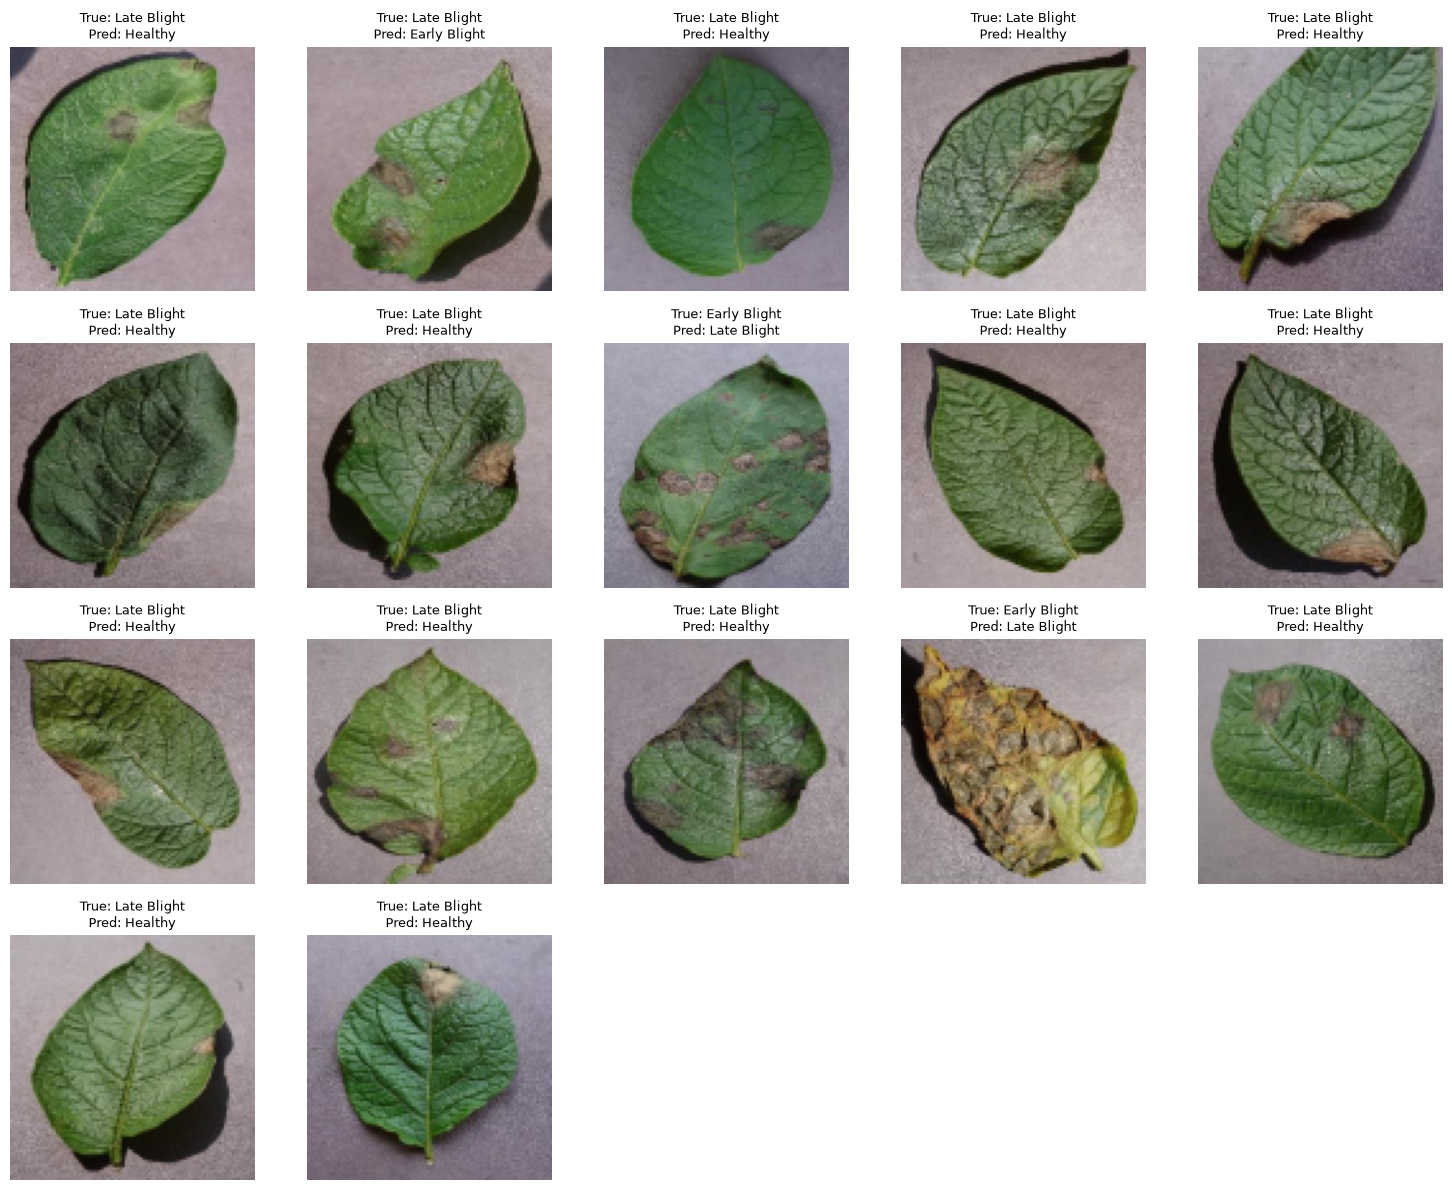

In [4]:
# ============================================================
# DISPLAY INCORRECT PREDICTIONS
# ============================================================

plt.figure(figsize=(15, 12))

for plot_num, idx in enumerate(wrong_indices):

    plt.subplot(4, 5, plot_num + 1)

    plt.imshow(X_test[idx])

    true_class = CLASS_DISPLAY[CLASSES[y_test[idx]]]
    predicted_class = CLASS_DISPLAY[CLASSES[y_pred[idx]]]

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    '../docs/potato_misclassified_images.png',
    dpi=150
)

plt.show()

In [5]:
# ============================================================
# LATE BLIGHT → HEALTHY ERRORS
# ============================================================

late_to_healthy = []

for idx in wrong_indices:

    true_class = y_test[idx]
    predicted_class = y_pred[idx]

    if (
        CLASSES[true_class] == 'Potato___Late_blight'
        and
        CLASSES[predicted_class] == 'Potato___healthy'
    ):
        late_to_healthy.append(idx)

print(
    f"Late Blight → Healthy errors: "
    f"{len(late_to_healthy)}"
)

Late Blight → Healthy errors: 14


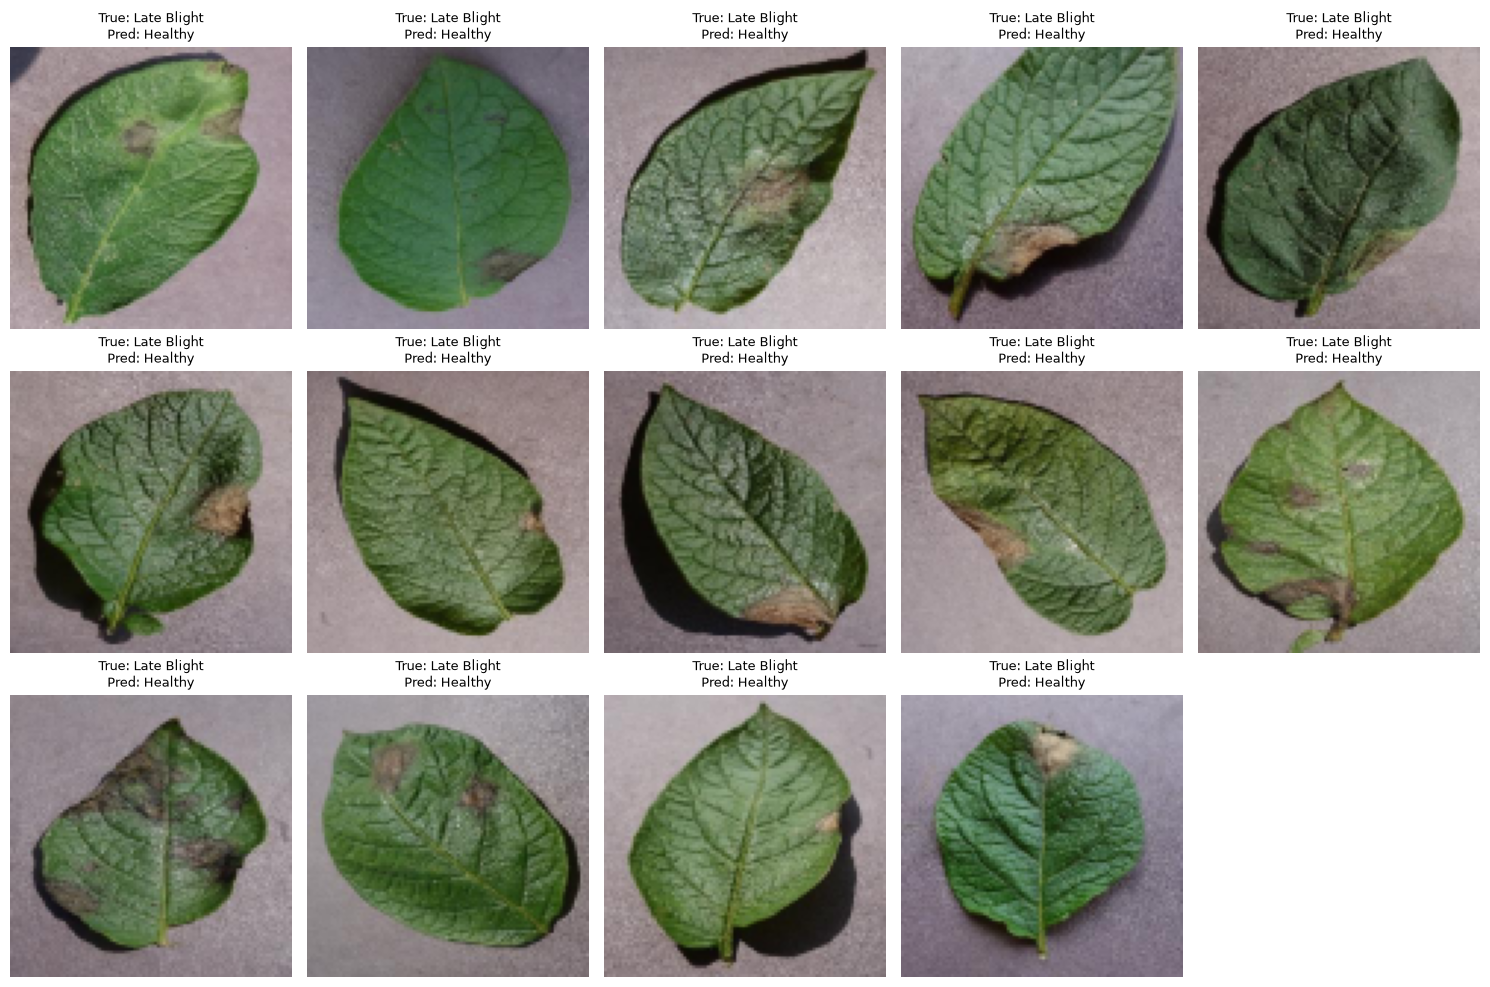

In [6]:
plt.figure(figsize=(15, 10))

for plot_num, idx in enumerate(late_to_healthy):

    plt.subplot(3, 5, plot_num + 1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: Late Blight\n"
        f"Pred: Healthy",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    '../docs/late_to_healthy_errors.png',
    dpi=150
)

plt.show()

In [7]:
# ============================================================
# CONFIDENCE OF INCORRECT PREDICTIONS
# ============================================================

print("\nIncorrect prediction confidence:\n")

for idx in wrong_indices:

    probabilities = y_probability[idx]

    predicted_class = y_pred[idx]
    confidence = probabilities[predicted_class]

    true_class = CLASS_DISPLAY[CLASSES[y_test[idx]]]
    predicted_name = CLASS_DISPLAY[CLASSES[predicted_class]]

    print(
        f"Index {idx} | "
        f"True: {true_class} | "
        f"Predicted: {predicted_name} | "
        f"Confidence: {confidence:.2%}"
    )


Incorrect prediction confidence:

Index 1 | True: Late Blight | Predicted: Healthy | Confidence: 53.84%
Index 22 | True: Late Blight | Predicted: Early Blight | Confidence: 56.39%
Index 69 | True: Late Blight | Predicted: Healthy | Confidence: 98.78%
Index 71 | True: Late Blight | Predicted: Healthy | Confidence: 58.54%
Index 85 | True: Late Blight | Predicted: Healthy | Confidence: 54.85%
Index 97 | True: Late Blight | Predicted: Healthy | Confidence: 98.37%
Index 125 | True: Late Blight | Predicted: Healthy | Confidence: 75.99%
Index 163 | True: Early Blight | Predicted: Late Blight | Confidence: 94.60%
Index 172 | True: Late Blight | Predicted: Healthy | Confidence: 82.65%
Index 188 | True: Late Blight | Predicted: Healthy | Confidence: 98.81%
Index 195 | True: Late Blight | Predicted: Healthy | Confidence: 55.55%
Index 216 | True: Late Blight | Predicted: Healthy | Confidence: 60.55%
Index 233 | True: Late Blight | Predicted: Healthy | Confidence: 80.98%
Index 236 | True: Early Bl